# Prepare Projected Population Data for Initial Year and Calibration Year

In [2]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

Go to root directory

In [3]:
if Path.cwd().name == "population_validation":
    os.chdir(Path.cwd().parent)

print(f"Current Directory: {Path.cwd()}")

Current Directory: /work/tuv89272/Calibration_Pipeline_v7_NG-SE


In [4]:
import sys
import _utils.utils as u

print("cwd:", Path.cwd())
print("utils loaded from:", u.__file__)
print()
for p in sys.path:
    print(p)

cwd: /work/tuv89272/Calibration_Pipeline_v7_NG-SE
utils loaded from: /work/tuv89272/Calibration_Pipeline_v7_NG-SE/_utils/utils.py

/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/work/tuv89272/Calibration_Pipeline_v7_NG-SE/.venv-ng-se/lib/python3.12/site-packages
__editable__.calibration_pipeline_ng_se-0.7.0.finder.__path_hook__


In [5]:
# print the contents of _configs.country_config 
with open("_configs/country_config.py", "r") as f:
    print(f.read())

# print the contents of _configs/files_config
# with open("_configs/files_config.py", "r") as f:
#     print(f.read())

country_code = "ng-se"
calibration_year = 2024
initial_year = 2011
observed_population_year = 2020

incidence_comparison_year = 2021

TARGET_POPULATION_CALIBRATION_YEAR = 26_716_457      # 2024
TARGET_POPULATION_INITIAL_YEAR = 20_357_567          # 2011

target_growth_rate = 0.02113 # From Excel sheet
birth_rate = 33.5 / 1000

# Paths
template_path = "calibration_template_files"
data_path = "DATA"
generated_data_path = "generated"

TEMPLATE = "input_population_bins.yml"


## Import Data From Rasters

In [6]:
districts_raster, _ = read_raster(districts_raster_path)
observed_population_raster, metadata = read_raster(observed_population_raster_path)

nodata = metadata["NODATA_value"]

if observed_population_raster.shape != districts_raster.shape:
    raise ValueError(
        f"Final population raster and district raster have different shapes: {observed_population_raster.shape} vs {districts_raster.shape}"
    )

# Get unique district IDs from full raster, excluding nodata
valid_districts = districts_raster[districts_raster != nodata]
unique_districts = np.unique(valid_districts).astype(int)

print("Unique District IDs:", unique_districts)

# Flatten full rasters
final_observed_population = observed_population_raster.flatten().astype(int)
district = districts_raster.flatten().astype(int)

# Keep only cells valid in all three rasters (initial population, final population, and district)
valid_mask = (
    (final_observed_population != nodata) &
    (district != nodata)
)

final_pop_valid = final_observed_population[valid_mask]
district_valid = district[valid_mask]

# Sum population values per district by using district ID as bin index and population as weight (zonal sum via bincount)
sum_final_population_per_district = np.bincount(district_valid, weights=final_pop_valid)

df = pd.DataFrame({
    f"district_id": unique_districts,
    f"observed_population_{observed_population_year}": [sum_final_population_per_district[d] for d in unique_districts],
})

total_final_population = df[f"observed_population_{observed_population_year}"].sum()
print(f"Total Observed Population in {observed_population_year}: {total_final_population:,.0f}")

df

Unique District IDs: [ 7  9 11 26 32 35]
Total Observed Population in 2020: 24,572,163


,district_id,observed_population_2020
0,7,6464378.0
1,9,4008484.0
2,11,3284316.0
3,26,2781807.0
4,32,4758921.0
5,35,3274257.0


## Total valid pixels

In [7]:
print("Total valid pixels:", valid_mask.sum())

Total valid pixels: 6851


## Generate Backwards Projected Population Raster for Initial Year

In [8]:
SCALE_FACTOR = TARGET_POPULATION_INITIAL_YEAR / df[f"observed_population_{observed_population_year}"].sum()

# Start from full raster
initial_population_projected_raster = observed_population_raster.astype(float).copy()

# Scale only valid cells
valid_mask = (
    (observed_population_raster != nodata) &
    (districts_raster != nodata)
)

initial_population_projected_raster[valid_mask] = np.round(observed_population_raster[valid_mask] * SCALE_FACTOR)

# Keep nodata cells unchanged
initial_population_projected_raster[~valid_mask] = nodata

write_raster(
    raster=initial_population_projected_raster,
    file=initial_population_projected_raster_path,
    xllcorner=metadata["xllcorner"],
    yllcorner=metadata["yllcorner"],
    cellsize=metadata["cellsize"],
    mask_raster=districts_raster,  # preserve nodata areas
    nodata=nodata,
    fmt="%d",
)

In [9]:
initial_population_projected_raster_to_verify, _ = read_raster(initial_population_projected_raster_path)

# Verify that the sum of the scaled population matches the target
target_population_projected_valid = initial_population_projected_raster_to_verify[valid_mask]
sum_target_population_projected_per_district = np.bincount(district_valid, weights=target_population_projected_valid)

print(f"Scale factor: {SCALE_FACTOR:.6f}")
print(f"Projected population in {calibration_year}: {target_population_projected_valid.sum():,.1f} (target: {TARGET_POPULATION_CALIBRATION_YEAR:,.1f})")

Scale factor: 0.828481
Projected population in 2024: 20,357,570.0 (target: 26,716,457.0)


## Generate Projected Population Raster for Calibration Year Using Observed Population Raster

In [10]:
SCALE_FACTOR = TARGET_POPULATION_CALIBRATION_YEAR / df[f"observed_population_{observed_population_year}"].sum()

# Start from full raster
target_year_population_projected_raster = observed_population_raster.astype(float).copy()

# Scale only valid cells
valid_mask = (
    (observed_population_raster != nodata) &
    (districts_raster != nodata)
)

target_year_population_projected_raster[valid_mask] = np.round(observed_population_raster[valid_mask] * SCALE_FACTOR)

# Keep nodata cells unchanged
target_year_population_projected_raster[~valid_mask] = nodata

write_raster(
    raster=target_year_population_projected_raster,
    file=projected_population_calibration_year_raster_path,
    xllcorner=metadata["xllcorner"],
    yllcorner=metadata["yllcorner"],
    cellsize=metadata["cellsize"],
    mask_raster=districts_raster,  # preserve nodata areas
    nodata=nodata,
    fmt="%d",
)

In [11]:
target_population_projected_raster, _ = read_raster(projected_population_calibration_year_raster_path)

# Verify that the sum of the scaled population matches the target
target_population_projected_valid = target_population_projected_raster[valid_mask]
sum_target_population_projected_per_district = np.bincount(district_valid, weights=target_population_projected_valid)

print(f"Scale factor: {SCALE_FACTOR}")
print(f"Projected population in {calibration_year}: {target_population_projected_valid.sum():,.1f} (target: {TARGET_POPULATION_CALIBRATION_YEAR:,.1f})")

Scale factor: 1.087265170754402
Projected population in 2024: 26,716,417.0 (target: 26,716,457.0)


## Plot Observed vs Projected Population Map Difference

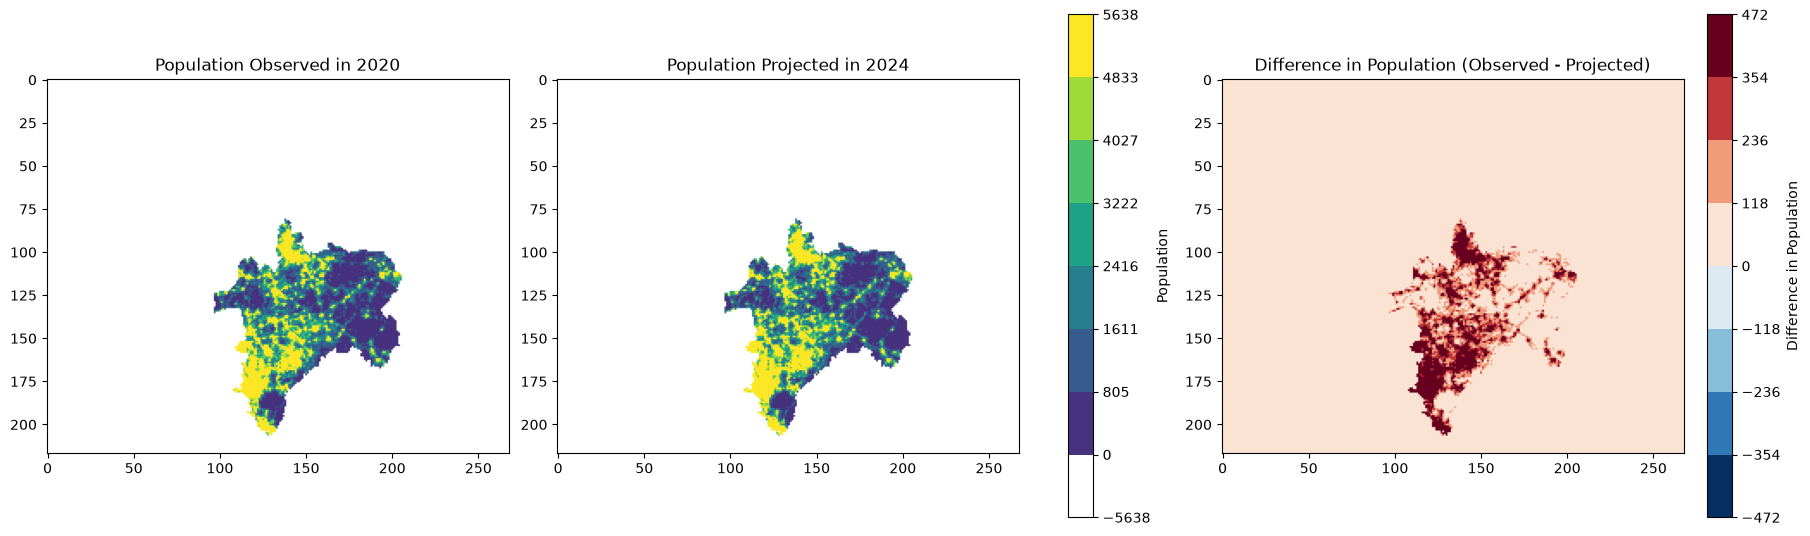

In [12]:
observed_population, _ = read_raster(observed_population_raster_path)
projected_population, _ = read_raster(projected_population_calibration_year_raster_path)

# Difference map (Projected - Observed)
population_difference = projected_population - observed_population

# Where sim is nodata but obs exists → sim "contributed 0", so diff = -obs
missing_sim_mask = ~np.isfinite(projected_population) & np.isfinite(observed_population)
population_difference[missing_sim_mask] = -observed_population[missing_sim_mask]

# Where obs is nodata (can't compare) → keep as NaN
population_difference[~np.isfinite(observed_population)] = np.nan

# -----------------------
# Robust linear limits (prevents outliers from crushing contrast)
# -----------------------
combined = np.r_[observed_population[np.isfinite(observed_population)].ravel(), projected_population[np.isfinite(projected_population)].ravel()]

# tweak these if needed
lo, hi = 2, 98
vmin = np.nanpercentile(combined, lo)
vmax = np.nanpercentile(combined, hi)

# -----------------------
# 8-band colormap for Population (Obs/Sim)
# -----------------------
n_bins = 8
bounds = np.r_[-vmax, 0, np.linspace(0, vmax, n_bins)[1:]]

base = plt.get_cmap("viridis", n_bins)        # discretize viridis into 8 colors
bg_white_color = np.array([[1,1,1,1]])
cmap_pop = ListedColormap(np.vstack([bg_white_color, plt.get_cmap("viridis", n_bins)(np.arange(1, n_bins))]))
norm_pop = BoundaryNorm(bounds, cmap_pop.N, clip=True)

# -----------------------
# 8-band diverging for Difference (symmetric, robust)
# -----------------------
dmax = np.nanpercentile(np.abs(population_difference[np.isfinite(population_difference)]), 98)
dbounds = np.linspace(-dmax, dmax, n_bins + 1)

base_d = plt.get_cmap("RdBu_r", n_bins)
cmap_diff = ListedColormap(base_d(np.arange(n_bins)))
norm_diff = BoundaryNorm(dbounds, cmap_diff.N, clip=True)

# -----------------------
# Plot
# -----------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

im0 = axes[0].imshow(observed_population, cmap=cmap_pop, norm=norm_pop, zorder=2)
axes[0].set_title(f"Population Observed in {observed_population_year}")

im1 = axes[1].imshow(projected_population, cmap=cmap_pop, norm=norm_pop, zorder=2)
axes[1].set_title(f"Population Projected in {calibration_year}")

im2 = axes[2].imshow(population_difference, cmap=cmap_diff, norm=norm_diff, zorder=2)
axes[2].set_title(f"Difference in Population (Observed - Projected)")

# Colorbars (banded)
cbar1 = fig.colorbar(im1, ax=axes[:2], shrink=0.85, boundaries=bounds)
cbar1.set_label("Population")
cbar1.set_ticks(bounds)  # show band edges (or use bounds[::2] for fewer ticks)

cbar2 = fig.colorbar(im2, ax=axes[2], shrink=0.85, boundaries=dbounds)
cbar2.set_label("Difference in Population")
cbar2.set_ticks(dbounds)

plt.savefig(f"{data_path}/observed_{observed_population_year}_vs_projected_{calibration_year}_population_pixel_maps.png", dpi=200)
plt.show()

### Write to csv

In [13]:
df[f'population_{calibration_year}_projected'] = df[f"observed_population_{observed_population_year}"] * SCALE_FACTOR

observed_population_sum = df[f"observed_population_{observed_population_year}"].sum()
projected_population_sum = df[f"population_{calibration_year}_projected"].sum()


# print(f'Initial population sum: {init_pop_sum:,.2f}')
print(f'Final population observed sum ({observed_population_year}): {observed_population_sum:,.2f}')
print(f'Final population projected sum ({calibration_year}): {projected_population_sum:,.2f}')

df.to_csv(population_per_district_projected_csv_path, index=False)

print(f"Wrote projected population per district to {population_per_district_projected_csv_path}")

Final population observed sum (2020): 24,572,163.00
Final population projected sum (2024): 26,716,457.00
Wrote projected population per district to generated/population_per_district_projected_2024.csv


# Prepare Incidence Data for Calibration Year to Compare to Results of Simulation

## Scale incidence from population

In [14]:
pop_df = pd.read_csv(population_per_district_projected_csv_path)
pop_df

,district_id,observed_population_2020,population_2024_projected
0,7,6464378.0,7.028493e+06
1,9,4008484.0,4.358285e+06
2,11,3284316.0,3.570922e+06
3,26,2781807.0,3.024562e+06
4,32,4758921.0,5.174209e+06
5,35,3274257.0,3.559986e+06


In [15]:
incidence_per_1000 = pd.read_csv(incidence_data_csv_path)
incidence_per_1000 = incidence_per_1000.dropna()
incidence_per_1000

,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,Population (2024 target based on worldometers birth rate and wordpop raster counts),Total Cases 2024 from projected population and observed incidence
0,Benue,7.0,257.2,"5,787,706","6,464,378",1.117,"6,601,202","1,697,829","7,028,225","1,807,659"
1,Cross_River,9.0,288.8,"4,175,020","4,008,484",0.960,"4,093,327","1,182,153","4,358,119","1,258,625"
2,Ebonyi,11.0,371.5,"3,007,155","3,284,316",1.092,"3,353,832","1,245,948","3,570,786","1,326,547"
3,Nassarawa,26.0,274.1,"2,632,239","2,781,807",1.057,"2,840,686","778,632","3,024,446","829,001"
4,Plateau,32.0,286.5,"4,400,974","4,758,921",1.081,"4,859,648","1,392,289","5,174,011","1,482,354"
5,Taraba,35.0,299.9,"3,331,885","3,274,257",0.983,"3,343,560","1,002,734","3,559,850","1,067,599"


In [16]:
data_df = pop_df.merge(incidence_per_1000, left_on="district_id", right_on="Region ID", how="left")
data_df

,district_id,observed_population_2020,population_2024_projected,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,Population (2024 target based on worldometers birth rate and wordpop raster counts),Total Cases 2024 from projected population and observed incidence
0,7,6464378.0,7.028493e+06,Benue,7.0,257.2,"5,787,706","6,464,378",1.117,"6,601,202","1,697,829","7,028,225","1,807,659"
1,9,4008484.0,4.358285e+06,Cross_River,9.0,288.8,"4,175,020","4,008,484",0.960,"4,093,327","1,182,153","4,358,119","1,258,625"
2,11,3284316.0,3.570922e+06,Ebonyi,11.0,371.5,"3,007,155","3,284,316",1.092,"3,353,832","1,245,948","3,570,786","1,326,547"
3,26,2781807.0,3.024562e+06,Nassarawa,26.0,274.1,"2,632,239","2,781,807",1.057,"2,840,686","778,632","3,024,446","829,001"
4,32,4758921.0,5.174209e+06,Plateau,32.0,286.5,"4,400,974","4,758,921",1.081,"4,859,648","1,392,289","5,174,011","1,482,354"
5,35,3274257.0,3.559986e+06,Taraba,35.0,299.9,"3,331,885","3,274,257",0.983,"3,343,560","1,002,734","3,559,850","1,067,599"


In [17]:
data_df

,district_id,observed_population_2020,population_2024_projected,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,Population (2024 target based on worldometers birth rate and wordpop raster counts),Total Cases 2024 from projected population and observed incidence
0,7,6464378.0,7.028493e+06,Benue,7.0,257.2,"5,787,706","6,464,378",1.117,"6,601,202","1,697,829","7,028,225","1,807,659"
1,9,4008484.0,4.358285e+06,Cross_River,9.0,288.8,"4,175,020","4,008,484",0.960,"4,093,327","1,182,153","4,358,119","1,258,625"
2,11,3284316.0,3.570922e+06,Ebonyi,11.0,371.5,"3,007,155","3,284,316",1.092,"3,353,832","1,245,948","3,570,786","1,326,547"
3,26,2781807.0,3.024562e+06,Nassarawa,26.0,274.1,"2,632,239","2,781,807",1.057,"2,840,686","778,632","3,024,446","829,001"
4,32,4758921.0,5.174209e+06,Plateau,32.0,286.5,"4,400,974","4,758,921",1.081,"4,859,648","1,392,289","5,174,011","1,482,354"
5,35,3274257.0,3.559986e+06,Taraba,35.0,299.9,"3,331,885","3,274,257",0.983,"3,343,560","1,002,734","3,559,850","1,067,599"


In [18]:
data_df.to_csv(f"{population_incidence_per_district_csv_path}", index=False)

print(f"Wrote population and incidence per district to {population_incidence_per_district_csv_path}")

Wrote population and incidence per district to generated/population_incidence_per_district.csv


### Birthrate from initial to calibration year based on initial population and final observed population

In [19]:
# period = calibration_year - initial_year
# population_diff = data_df[f'final_population_{calibration_year}_projected'] - data_df['init_population']
# change_each_year = population_diff / period

# # Build a neat summary table
# result_df = data_df[["district_id", "init_population", f'final_population_{calibration_year}_projected']].copy()
# result_df["population_diff"] = population_diff
# result_df["change_per_year"] = change_each_year

# # Formatters for nice printing
# formatters = {
#     "district_id": lambda x: f"{int(x)}",
#     "init_population": lambda x: f"{x:,.0f}",
#     f'final_population_{calibration_year}_projected': lambda x: f"{x:,.0f}",
#     "population_diff": lambda x: f"{x:,.0f}",
#     "change_per_year": lambda x: f"{x:,.2f}",
# }

# print(f"Population change per district over {period} years (average per year):\n")
# print(result_df.to_string(index=False, formatters=formatters))